In [1]:
#Install dependecies
#Install mysql connector
!pip install mysql-connector-python sqlalchemy pymysql
#install sql magic
!pip install ipython-sql

   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/16.5 MB ? eta -:--:--
    --------------------------------------- 0.3/16.5 MB ? eta -:--:--
   - -------------------------------------- 0.5/16.5 MB 1.1 MB/s eta 0:00:15
   -- ------------------------------------- 1.0/16.5 MB 1.7 MB/s eta 0:00:10
   -- ------------------------------------- 1.0/16.5 MB 1.7 MB/s eta 0:00:10
   --- ------------------------------------ 1.6/16.5 MB 1.7 MB/s eta 0:00:09
   ---- ----------------------------------- 1.8/16.5 MB 1.6 MB/s eta 0:00:09
   ---- ----------------------------------- 1.8/16.5 MB 1.6 MB/s eta 0:00:09
   ----- ---------------------------------- 2.1/16.5 MB 1.2 MB/s eta 0:00:13
   ------ --------------------------------- 2.9/16.5 MB 1.6 MB/s eta 0:00:09
   ------- -----------------------

In [26]:
import mysql.connector
import pandas as pd
conn=mysql.connector.connect(host="localhost",
                            port=3306,
                            user="root",
                            password="",
                            database="hr")
cursor=conn.cursor()
sql="SELECT * FROM employees"
cursor.execute(sql)
emp_dt=cursor.fetchall()
df=pd.read_sql(sql,conn)
df


C:\Users\HP\AppData\Local\Temp\ipykernel_3528\1775518282.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df=pd.read_sql(sql,conn)


,EMP_ID,F_NAME,L_NAME,SSN,B_DATE,SEX,ADDRESS,JOB_ID,SALARY,MANAGER_ID,DEP_ID
0,E1001,John,Thomas,123456,1976-09-01,M,"5631 Rice, OakPark,IL",100,100000.0,30001,2
1,E1002,Alice,James,123457,1972-07-31,F,"980 Berry ln, Elgin,IL",200,80000.0,30002,5
2,E1003,Steve,Wells,123458,1980-10-08,M,"291 Springs, Gary,IL",300,50000.0,30002,5
3,E1004,Santosh,Kumar,123459,1985-07-20,M,"511 Aurora Av, Aurora,IL",400,60000.0,30002,5
4,E1005,Ahmed,Hussain,123410,1981-04-01,M,"216 Oak Tree, Geneva,IL",500,70000.0,30001,2
5,E1006,Nancy,Allen,123411,1978-06-02,F,"111 Green Pl, Elgin,IL",600,90000.0,30001,2
6,E1007,Mary,Thomas,123412,1975-05-05,F,"100 Rose Pl, Gary,IL",650,65000.0,30003,7
7,E1008,Bharath,Gupta,123413,1985-06-05,M,"145 Berry Ln, Naperville,IL",660,65000.0,30003,7
8,E1009,Andrea,Jones,123414,1990-09-07,F,"120 Fall Creek, Gary,IL",234,70000.0,30003,7
9,E1010,Ann,Jacob,123415,1982-03-30,F,"111 Britany Springs,Elgin,IL",220,70000.0,30002,5


In [19]:
%load_ext sql

In [30]:
import sqlite3
con=mysql.connector.connect(host="localhost",
                            port=3306,
                            user="root",
                            password="",
                            database="hr")


SyntaxError: invalid syntax (730816587.py, line 10)

In [31]:
%load_ext sql

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [34]:
!pip install ipython-sql prettytable
import prettytable
prettytable.DEFAULT='DEFAULT'

In [35]:
%%sql mysql+mysqlconnector://root@localhost/hr

UPDATE employees SET F_NAME='Edward' WHERE F_NAME='John';
SELECT * FROM employees;

0 rows affected.
10 rows affected.


EMP_ID,F_NAME,L_NAME,SSN,B_DATE,SEX,ADDRESS,JOB_ID,SALARY,MANAGER_ID,DEP_ID
E1001,Edward,Thomas,123456,1976-09-01,M,"5631 Rice, OakPark,IL",100,100000.00,30001,2
E1002,Alice,James,123457,1972-07-31,F,"980 Berry ln, Elgin,IL",200,80000.00,30002,5
E1003,Steve,Wells,123458,1980-10-08,M,"291 Springs, Gary,IL",300,50000.00,30002,5
E1004,Santosh,Kumar,123459,1985-07-20,M,"511 Aurora Av, Aurora,IL",400,60000.00,30002,5
E1005,Ahmed,Hussain,123410,1981-04-01,M,"216 Oak Tree, Geneva,IL",500,70000.00,30001,2
E1006,Nancy,Allen,123411,1978-06-02,F,"111 Green Pl, Elgin,IL",600,90000.00,30001,2
E1007,Mary,Thomas,123412,1975-05-05,F,"100 Rose Pl, Gary,IL",650,65000.00,30003,7
E1008,Bharath,Gupta,123413,1985-06-05,M,"145 Berry Ln, Naperville,IL",660,65000.00,30003,7
E1009,Andrea,Jones,123414,1990-09-07,F,"120 Fall Creek, Gary,IL",234,70000.00,30003,7
E1010,Ann,Jacob,123415,1982-03-30,F,"111 Britany Springs,Elgin,IL",220,70000.00,30002,5


In [38]:
Age_v_salary=%sql SELECT SALARY,(YEAR(CURRENT_DATE)-YEAR(B_DATE)) as age FROM employees
Age_v_salary

 * mysql+mysqlconnector://root@localhost/hr
10 rows affected.


SALARY,age
100000.00,50
80000.00,54
50000.00,46
60000.00,41
70000.00,45
90000.00,48
65000.00,51
65000.00,41
70000.00,36
70000.00,44


In [39]:
!pip install seaborn

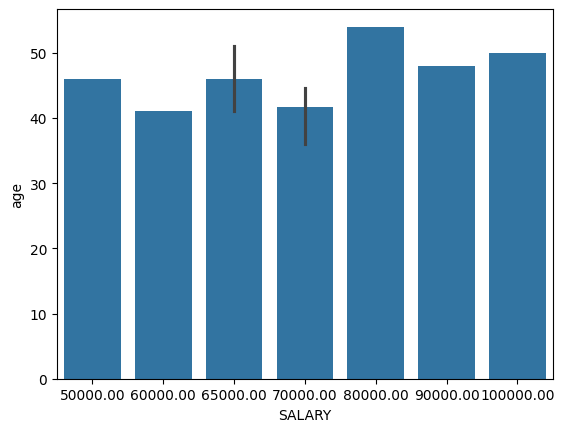

In [46]:
import seaborn
dataframe=Age_v_salary.DataFrame()
%matplotlib inline
plot=seaborn.barplot(x='SALARY',y='age',data=dataframe)


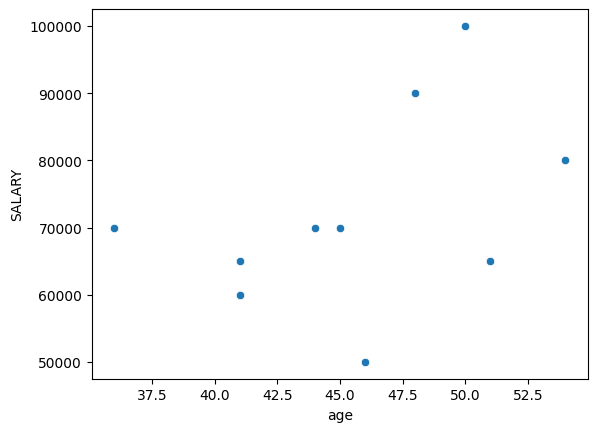

In [52]:
%matplotlib inline
plot=seaborn.scatterplot(x='age' ,y='SALARY', data=dataframe)

In [55]:
SALARY_V_DEPT=%sql SELECT DEP_ID, SALARY FROM employees GROUP BY DEP_ID
SALARY_V_DEPT

 * mysql+mysqlconnector://root@localhost/hr
3 rows affected.


DEP_ID,SALARY
2,100000.00
5,80000.00
7,65000.00


<Axes: xlabel='DEP_ID', ylabel='SALARY'>

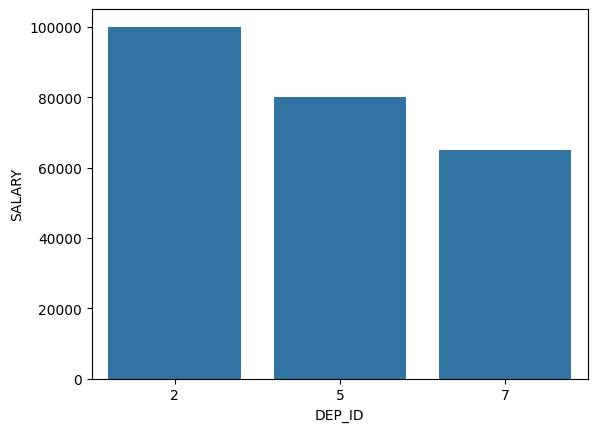

In [57]:
df=SALARY_V_DEPT.DataFrame()
%matplotlib inline
plot=seaborn.barplot(x='DEP_ID', y='SALARY' , data=df)
plot

In [59]:
import sqlite3
con=sqlite3.connect("socioeconomic.db")
cur=con.cursor()


In [61]:
%sql sqlite3://socioeconomic.db

Traceback (most recent call last):
  File "C:\Users\HP\anaconda3\envs\pytr\Lib\site-packages\sql\connection.py", line 45, in __init__
    engine = sqlalchemy.create_engine(
        connect_str, connect_args=connect_args
    )
  File "<string>", line 2, in create_engine
  File "C:\Users\HP\anaconda3\envs\pytr\Lib\site-packages\sqlalchemy\util\deprecations.py", line 281, in warned
    return fn(*args, **kwargs)  # type: ignore[no-any-return]
  File "C:\Users\HP\anaconda3\envs\pytr\Lib\site-packages\sqlalchemy\engine\create.py", line 568, in create_engine
    entrypoint = u._get_entrypoint()
  File "C:\Users\HP\anaconda3\envs\pytr\Lib\site-packages\sqlalchemy\engine\url.py", line 772, in _get_entrypoint
    cls = registry.load(name)
  File "C:\Users\HP\anaconda3\envs\pytr\Lib\site-packages\sqlalchemy\util\langhelpers.py", line 350, in load
    raise exc.NoSuchModuleError(
        "Can't load plugin: %s:%s" % (self.group, name)
    )
sqlalchemy.exc.NoSuchModuleError: Can't load plugin: sql

In [65]:
import sqlite3

import pandas as pd

conn = sqlite3.connect(HR.db)

data = pd.read_csv(./employees.csv)

data.to_sql(Employees, conn)

SyntaxError: invalid syntax (3511346451.py, line 7)